# Exercise 6: Normalizing Flow

Submitted by:

 **Student 1 : Baruh Riss 318739174**

 **Student 2 : Amir Ammar 205744873**

<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>


## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [5]:
## Standard libraries
import os
import math
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from IPython.display import set_matplotlib_formats
%config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [6]:
def dequantize_mnist(img):
    x = torch.from_numpy(np.array(img, dtype=np.float32)).unsqueeze(0)
    return (x + torch.rand_like(x)) / 256.0

# Continuous representation: add U[0, 1] noise to integer pixels, then scale by 256.
transform = transforms.Compose([
    transforms.Lambda(dequantize_mnist),
])

# Loading the training dataset. We split it into train and validation parts.
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

split_generator = torch.Generator().manual_seed(42)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000], generator=split_generator)

# Loading the test set.
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# Data loaders used for training, validation, testing, and visualization.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))


Train size: 50000
Validation size: 10000
Test size: 10000


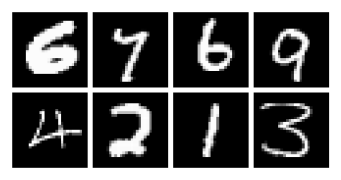

In [3]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

## Task 1: Normalizing Flow


# Deep Dive: Normalizing Flow (RealNVP) Implementation

This code implements a **Normalizing Flow**, specifically heavily inspired by the **RealNVP** (Real-valued Non-Volume Preserving) architecture. The fundamental theory behind Normalizing Flows is to take a complex, unknown data distribution (like images of digits) and transform it into a simple, known prior distribution (like a standard Gaussian $\mathcal{N}(0,I)$) using a sequence of invertible, differentiable transformations. 

Because the transformations are strictly invertible, we can train the model in the "forward" direction (Images $\to$ Noise) using exact maximum likelihood, and then run it in "reverse" (Noise $\to$ Images) to generate brand new data.

Here is a deep theoretical breakdown of every component in the code.

---

### 1. The Neural Networks: `CouplingMLP`
In an affine coupling layer, we need neural networks to predict how much to **scale** ($s_\theta$) and **shift** ($m_\theta$) the data. 
* **The Architecture:** It's a standard 5-layer Multi-Layer Perceptron (MLP) with ReLU activations.
* **The Scale Constraint (`nn.Tanh`):** If this MLP is predicting the scale $s$, its final activation is a `Tanh`. Why? In the flow, we multiply data by $\exp(s)$. If $s$ becomes too large, $\exp(s)$ explodes to infinity (`NaN`), destroying training. Bounding $s$ between -1 and 1 via `Tanh` keeps $\exp(s)$ safely between $\approx 0.36$ and $2.71$.
* **The Identity Trick:** `initialize_last_layer_near_identity` sets the final weights/biases to 0. This ensures that at epoch 0, the MLP outputs exactly 0. Since $\exp(0) = 1$ and shift is $0$, the flow starts off doing absolutely nothing (it acts as an identity function). This is a crucial trick in deep generative models to prevent initial numerical instability.

---

### 2. The Core Math: `AffineCouplingLayer`

This is the heart of the RealNVP architecture. The biggest challenge in Normalizing Flows is that calculating the Jacobian determinant of a massive neural network is computationally impossible $\mathcal{O}(D^3)$. 

RealNVP bypasses this by masking the input and applying transformations to only half the data at a time, forcing the Jacobian matrix to be strictly **triangular**. The determinant of a triangular matrix is just the sum of its diagonal!

* **The Forward Pass (Data $\to$ Noise):**
  1. The input $x$ is split into two halves using a binary `mask`: $x_{fixed}$ (unchanged) and $x_{change}$ (to be transformed).
  2. The unchanging half $x_{fixed}$ is passed through the MLPs to generate the scale $s$ and shift $m$.
  3. The changing half is updated via the affine equation: $z_{change} = x_{change} \odot \exp(s) + m$.
  4. **The Log-Determinant:** Because of the triangular structure, the volume change of this entire layer is simply the sum of the scale factors: `log_det_jacobian = s.sum(dim=1)`.
* **The Inverse Pass (Noise $\to$ Data):**
  To go backwards, we simply reverse the algebra. We subtract the shift $m$ and divide by $\exp(s)$ (which is the same as multiplying by $\exp(-s)$): 
  $x_{change} = (z_{change} - m) \odot \exp(-s)$.

---

### 3. Bridging the Boundaries: `image_to_flow_input`
Images are discrete pixels bounded between $[0, 1]$. However, our target prior is a Gaussian distribution, which stretches from $[-\infty, \infty]$. If we feed bounded pixels directly into the flow, the math breaks at the edges.

* **Logit Transform:** To fix this, the code applies a mathematical trick. It slightly shrinks the pixels away from 0 and 1 using `alpha` (e.g., bounds them to $[10^{-5}, 0.99999])$, and then applies the **Logit function**: $y = \log(u) - \log(1-u)$. 
* This elegantly stretches the bounded image space out to infinity, making it perfectly compatible with a Gaussian distribution.
* **Log-Det Tracking:** Because this Logit transform physically stretches the space, we must mathematically track its volume change (`log_det_logit`) and add it to our running total, or our probability calculations will be wrong.

---

### 4. Tying it Together: `NormalizingFlow`
This class stacks 10 `AffineCouplingLayer`s together. 
* **Alternating Masks:** If we only ever modified the second half of the image, the first half would never be transformed! The `create_checkerboard_mask` creates a spatial grid (like a chessboard). The `__init__` function specifically alternates this mask (`1.0 - base_mask`) layer by layer. This ensures that pixels that were $x_{fixed}$ in Layer 1 become $x_{change}$ in Layer 2.
* **Forward / Inverse Loops:** The `forward` method pushes data through all 10 layers, continuously accumulating the `log_det_jacobian`. The `inverse` method runs the layers in reverse order for generation.

---

### 5. The Training Objective: `calc_nll`
This is where the **Change of Variables Theorem** from calculus is applied to train the network. To maximize the likelihood of our data, we minimize the Negative Log-Likelihood (NLL).

The formula is:
$$\mathcal{L}(x) = - \log p_X(x) = - \left( \log p_Z(z) + \log \left| \det \frac{\partial z}{\partial x} \right| \right)$$

In code, this translates perfectly to:
```python
log_prob_x = self.prior_log_prob(z) + log_det_jacobian
return -log_prob_x.mean()

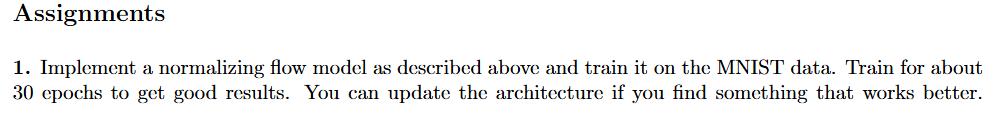
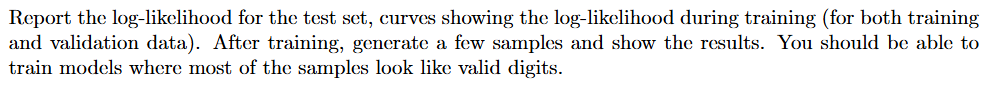

In [ ]:
MODEL_VERSION = 'nf_logit_checkerboard_v2'


```markdown
## The "Zero-Initialization" Identity Trick in Normalizing Flows

In the `CouplingMLP` class, we use a very specific initialization strategy for the final linear layer:

```python
def initialize_last_layer_near_identity(self):
    last_layer = self.net[-2] # The final nn.Linear layer before Tanh
    nn.init.zeros_(last_layer.weight)
    nn.init.zeros_(last_layer.bias)

```

While initializing weights to exactly zero is notoriously avoided in standard deep learning (due to the "symmetry breaking" problem where neurons fail to learn independent features), it is an absolutely **critical architectural requirement** for training deep Normalizing Flows like RealNVP or Glow.

Here is the deep mathematical theory behind why this trick is required to prevent immediate model collapse.

---

### 1. The Threat of the Exponential Scale

In an affine coupling layer, the transformation equation for the modified half of the data ($x_2$) is:

$$x_2^{new} = x_2^{old} \odot \exp(s_\theta(x_1)) + m_\theta(x_1)$$

The scale network, $s_\theta$, outputs a vector. We take the exponent of that vector, $\exp(s_\theta)$, and multiply it by our data.

**What happens if we use standard random initialization (like Xavier or Kaiming)?**
If we randomly initialize the weights of the MLP, the output of $s_\theta$ at Epoch 0 will be a vector of random numbers (e.g., normally distributed between -2 and 2).

* If $s_\theta = 2$, then $\exp(2) \approx 7.38$. The layer amplifies the data by $7.38\times$.
* If $s_\theta = -2$, then $\exp(-2) \approx 0.13$. The layer shrinks the data by nearly $90\%$.

### 2. The Compounding Explosion

Remember that a deep `NormalizingFlow` stacks **many of these layers** sequentially (e.g., 10 layers in your current architecture).

If the data is randomly multiplied by $7.38$ ten times in a row, the variance of the data explodes exponentially ($7.38^{10} \approx 480,000,000$). If it shrinks by $0.13$ ten times, the data collapses entirely to zero.

Because the loss function calculates $-\log p_Z(z)$ alongside the log-determinant of these scaling factors, this random, aggressive exponential scaling causes the gradients to instantly explode to `NaN` (Not a Number) or `Inf` on the very first forward pass. The training will crash before a single successful optimization step can be taken.

---

### 3. The Identity Function Rescue

To prevent this catastrophic numerical explosion, we mathematically force the entire Normalizing Flow model to start its life doing absolutely nothing. We want it to act as a perfect **Identity Function** ($f(x) = x$).

To achieve $f(x) = x$ in our coupling equation, we need:

1. $\exp(s_\theta) = 1 \implies$ **$s_\theta$ must output exactly $0$.**
2. $m_\theta = 0 \implies$ **$m_\theta$ must output exactly $0$.**

By setting the weights and biases of the *very last layer* of our MLPs to exactly zero, we guarantee that no matter what random features the first 4 layers of the MLP compute, the final output will be multiplied by zero, resulting in exactly $0$.

---

### 4. Why it Works (Optimization Dynamics)

When the model starts out as a perfect Identity function:

* The input image $x$ passes completely unchanged through all 10 layers, emerging as $z = x$.
* The log-determinant of the Jacobian is exactly $0$ for all layers ($\sum \log(1) = 0$).
* The gradients calculated on the first batch are incredibly stable because the network isn't doing any wild exponential stretching yet.

As training progresses (Epoch 1, 2, 3...), the optimizer calculates safe, finite gradients and slowly pushes the weights of that final layer away from zero. The network smoothly and gradually "wakes up," learning to apply gentle scales and shifts to warp the data towards the Gaussian prior without ever triggering numerical collapse.

### Summary

In standard CNNs, we initialize randomly to break symmetry. In Normalizing Flows, we initialize the final layer to zero to enforce mathematical stability. Without this zero-initialization trick, the chained $\exp(s)$ calculations would mathematically detonate the network before it could learn a single feature.

```

```

In [7]:


class CouplingMLP(nn.Module):
    """
    Multi-Layer Perceptron (MLP) for predicting the affine coupling parameters.
    
    In a Normalizing Flow, we must calculate a scale (s) and a translation (m) 
    factor. Because the Jacobian determinant of the affine transformation only 
    depends on the scale factor, this neural network does NOT need to be strictly 
    invertible itself. We can use highly non-linear transformations (like ReLU) 
    to learn complex mappings from the fixed half of the data to the parameters 
    that will modify the changing half.
    """

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            # Tanh bounds the output to [-1, 1]. In the coupling layer, we will do 
            # torch.exp(s). Bounding s prevents exp(s) from exploding to infinity, 
            # ensuring numerical stability during the forward/inverse passes.
            nn.Tanh(),
        )
        self.initialize_last_layer_near_identity()

    def initialize_last_layer_near_identity(self):
        """
        Zero-initialization trick for Normalizing Flows.
        
        By setting the final layer's weights and biases to exactly 0, the MLP 
        initially outputs 0 for all inputs. Because exp(0) = 1 (identity scale) 
        and shift = 0 (identity translation), the entire flow model starts as a 
        perfect Identity function. This prevents extreme gradients early in 
        training and stabilizes the optimization process.
        """
        last_layer = self.net[-2] # Index -2 is the final nn.Linear layer
        nn.init.zeros_(last_layer.weight)
        nn.init.zeros_(last_layer.bias)

    def forward(self, x):
        return self.net(x)


## The Heart of RealNVP: The Affine Coupling Layer

This class implements the mathematical engine of the Normalizing Flow. To train a generative model using exact likelihood, we face a massive paradox: we need a neural network that is **highly expressive** (to learn complex data like images), strictly **invertible** (to go back and forth between data and noise), and allows for incredibly **cheap Jacobian determinant calculations** (to track volume changes).

Standard neural networks fail all of these requirements. The **Affine Coupling Layer** solves them all using a brilliant mathematical workaround.



Here is the deep theoretical breakdown of how the code achieves this.

---

### 1. The Partitioning Strategy (The Mask)

```python
x_fixed = x * self.mask
change_mask = 1.0 - self.mask

```

The fundamental trick of a coupling layer is that it **refuses to process all the data at once**. Instead, it splits the input dimensions $x$ into two groups using a binary mask (e.g., a checkerboard pattern).

* **$x_{fixed}$ (Group 1):** This half of the pixels is left completely untouched.
* **$x_{change}$ (Group 2):** This half of the pixels will be transformed, but the transformation rules are dictated entirely by Group 1.

By using `self.register_buffer('mask', ...)`, the PyTorch module saves this static mask as part of its internal state, ensuring it automatically travels to the GPU alongside the model's trainable weights.

---

### 2. The Forward Pass: Data $\to$ Noise

```python
s = self.s_net(x_fixed) * change_mask
m = self.m_net(x_fixed) * change_mask
z = x_fixed + change_mask * (x * torch.exp(s) + m)

```

Instead of pushing the changing pixels ($x_{change}$) through a complex, hard-to-invert neural network, we push the *unchanging* pixels ($x_{fixed}$) through our deep MLPs to predict two parameter vectors:

1. **Scale ($s$):** How much to stretch/squish the changing pixels.
2. **Translation ($m$):** How much to shift the changing pixels.

We then apply a simple linear (affine) equation to the changing half:


$$z_{change} = x_{change} \odot \exp(s(x_{fixed})) + m(x_{fixed})$$

Because we take $\exp(s)$, the scale factor is strictly positive, guaranteeing the transformation never collapses to zero and is always mathematically invertible.

---

### 3. The Mathematical Miracle: The Jacobian

```python
log_det_jacobian = s.sum(dim=1)

```

This single line of code replaces an algorithm that would normally take $\mathcal{O}(D^3)$ time and make deep flows impossible.

The Jacobian matrix tracks the derivative of every output with respect to every input. Because $z_{fixed}$ only depends on $x_{fixed}$, and $z_{change}$ depends on both, the resulting Jacobian matrix is **strictly lower-triangular**:

* The top-left quadrant is an Identity matrix (since $x_{fixed}$ doesn't change).
* The top-right quadrant is all zeros (since $x_{fixed}$ doesn't depend on $x_{change}$).
* The bottom-right quadrant is a diagonal matrix containing our scaling factors: $\exp(s)$.

In linear algebra, the determinant of any triangular matrix is just the product of its diagonal.


$$\det(J) = \prod \exp(s)$$


When we take the log of that determinant (which we need for the NLL loss), the product of exponentials beautifully simplifies to the sum of the raw scale parameters:


$$\log(\det(J)) = \sum s$$

---

### 4. The Inverse Pass: Noise $\to$ Data

```python
z_fixed = z * self.mask
s = self.s_net(z_fixed) * change_mask
m = self.m_net(z_fixed) * change_mask
x = z_fixed + change_mask * ((z - m) * torch.exp(-s))

```

This is where the architecture proves its genius. How do we invert a deep, complex neural network with ReLU activations? **We don't have to.**

1. Because the first half of the data never changed during the forward pass, we already know that $z_{fixed} = x_{fixed}$.
2. Because we have the exact original $x_{fixed}$, we can feed it right back into the forward direction of our MLPs ($s\_net$ and $m\_net$).
3. The MLPs will output the **exact same** $s$ and $m$ parameters that were used during the forward pass.
4. We just reverse the simple affine algebra to solve for the original pixels:

$$x_{change} = \frac{z_{change} - m}{\exp(s)} = (z_{change} - m) \odot \exp(-s)$$



We achieved a perfectly invertible layer powered by highly non-linear neural networks, without ever needing to mathematically invert the neural networks themselves!

```


In [8]:
class AffineCouplingLayer(nn.Module):
    """
    RealNVP-style Affine Coupling Layer.
    
    This layer implements the core invertible transformation. By splitting the 
    dimensions into two parts and only applying the transformation to one part 
    conditioned on the other, the Jacobian matrix becomes strictly lower-triangular. 
    This is a massive theoretical breakthrough because the determinant of a 
    triangular matrix is simply the product of its diagonal, reducing a computationally 
    impossible O(D^3) matrix operation to a simple O(D) sum.
    """

    def __init__(self, input_dim, hidden_dim, mask):
        super().__init__()
        # Register mask as a buffer so it automatically moves to the correct device (GPU/CPU)
        self.register_buffer('mask', mask.view(1, input_dim))
        self.s_net = CouplingMLP(input_dim, hidden_dim, input_dim)
        self.m_net = CouplingMLP(input_dim, hidden_dim, input_dim)

    def forward(self, x):
        """
        Transforms data towards the latent space (x -> z).
        """
        # x_fixed (x1): The portion of the data left completely untouched.
        x_fixed = x * self.mask
        change_mask = 1.0 - self.mask

        # The unmodified data dictates the parameters for transforming the rest.
        s = self.s_net(x_fixed) * change_mask
        m = self.m_net(x_fixed) * change_mask

        # Affine Transformation: x2' = x2 * exp(s) + m
        # We use masking instead of slicing to preserve tensor shapes for vectorized GPU operations.
        z = x_fixed + change_mask * (x * torch.exp(s) + m)
        
        # Log-Determinant of the Jacobian:
        # Since the Jacobian is triangular, det(J) = prod(diag(J)).
        # The diagonal elements are exp(s). Therefore, log(det(J)) = sum(s).
        log_det_jacobian = s.sum(dim=1)
        
        return z, log_det_jacobian

    def inverse(self, z):
        """
        Transforms latent noise back towards the data distribution (z -> x).
        """
        # z_fixed is mathematically identical to x_fixed. It did not change during the forward pass.
        z_fixed = z * self.mask
        change_mask = 1.0 - self.mask

        # Because z_fixed == x_fixed, passing it through the MLPs yields the EXACT same s and m.
        s = self.s_net(z_fixed) * change_mask
        m = self.m_net(z_fixed) * change_mask

        # Inverse Affine Transformation: x2 = (x2' - m) / exp(s)
        # We multiply by exp(-s) instead of dividing for numerical stability.
        x = z_fixed + change_mask * ((z - m) * torch.exp(-s))
        return x



## Orchestrating the Flow: The `NormalizingFlow` Class

The `NormalizingFlow` class acts as the central orchestrator. It stitches together the raw, discrete image data, the mathematical boundary transformations (Logit/Sigmoid), and the deep stack of `AffineCouplingLayer`s into a single, cohesive generative model.



This class is responsible for computing the exact Negative Log-Likelihood (NLL) using the Change of Variables theorem, which serves as the training objective. Here is a deep theoretical breakdown of its core components.

---

### 1. The Masking Strategy: Breaking the Symmetry

```python
base_mask = self.create_checkerboard_mask(image_shape)
masks = [base_mask if layer_idx % 2 == 0 else 1.0 - base_mask for layer_idx in range(num_layers)]

```

In an `AffineCouplingLayer`, exactly half of the pixels are left completely unchanged. If we used the exact same mask for all 10 layers, half of the image would *never* be transformed, and the network would fail to model the joint probability of the entire image.

To solve this, we must **alternate the mask**.

* **Layer 1:** Uses `base_mask`. The "black" squares of the checkerboard are fixed, and the "white" squares are transformed.
* **Layer 2:** Uses `1.0 - base_mask`. The roles reverse. The "white" squares are now fixed, and the "black" squares (which were just transformed in Layer 1) are transformed again based on the new context.

This alternating spatial checkerboard ensures that local dependencies (how a pixel relates to its immediate neighbors) are thoroughly mixed and modeled across the depth of the flow.

---

### 2. Boundary Management: `image_to_flow_input`

Images consist of discrete pixel intensities bounded between $[0, 1]$. However, our goal is to map these pixels to a Gaussian prior distribution, $\mathcal{N}(0, I)$, which is defined over the entire real number line $[-\infty, \infty]$.

If we feed $[0, 1]$ directly into the flow, the mathematics will struggle at the hard boundaries. We must stretch the bounded space into infinite space.

```python
u = self.alpha + (1.0 - 2.0 * self.alpha) * x
y = torch.logit(u)

```

1. **Squeezing:** We first squeeze the data slightly away from $0$ and $1$ using an `alpha` margin (e.g., $10^{-5}$). This prevents the next step from evaluating $\log(0)$, which results in `NaN`.
2. **The Logit Transform:** We apply the inverse sigmoid function, $y = \log(\frac{u}{1-u})$. This elegantly maps values near $0$ to $-\infty$ and values near $1$ to $+\infty$, creating an unbounded continuous space $\mathbb{R}^n$ perfectly suited for Gaussian mapping.

```python
log_det_logit = (math.log(1.0 - 2.0 * self.alpha) - torch.log(u) - torch.log1p(-u)).sum(dim=1)

```

**Crucially**, because we mathematically stretched the space, we must account for the change in volume. The derivative of the logit function gives us this exact `log_det_logit` correction term, which is added to our running Jacobian accumulator.

---

### 3. The Core Objective: `calc_nll`

This is the exact mathematical implementation of the Change of Variables theorem:


$$\log p_X(x) = \log p_Z(f(x)) + \log \left| \det \left( \frac{\partial f(x)}{\partial x} \right) \right|$$

```python
z, log_det_jacobian = self.forward(x)
log_prob_x = self.prior_log_prob(z) + log_det_jacobian
return -log_prob_x.mean()

```

This loss function represents a perfect "tug-of-war" during training:

1. **`prior_log_prob(z)`:** This term acts like a vacuum. It calculates the log-probability of the transformed point $z$ under a standard Normal distribution $\mathcal{N}(0, I)$. It heavily penalizes the model if $z$ ends up far away from the origin $0$. The network wants to squish everything to $0$ to minimize this penalty.
2. **`log_det_jacobian`:** This term acts as the referee. It sums up all the `s_theta` scale factors from the 10 layers. If the network tries to cheat by infinitely squishing the data to $0$, this log-determinant becomes massively negative, resulting in a huge penalty.

By minimizing the *negative* mean of this sum, the neural network learns a perfect, balanced mapping. It learns how to untangle the chaotic distribution of human handwriting into a neat, orderly Gaussian distribution *without* mathematically collapsing the space.

```


---
## Deep Dive: Feedforward and Backpropagation in Normalizing Flows

In Normalizing Flows, it is crucial to distinguish between three different directional flows. 
1. **Feedforward (Forward Pass):** Maps Data $\to$ Noise to calculate the exact likelihood (Loss).
2. **Inverse Pass:** Maps Noise $\to$ Data to generate new samples.
3. **Backpropagation:** The standard Deep Learning process of passing error gradients backward through the computational graph to update the weights of our MLPs.

Here is the deep mathematical breakdown of what happens during the **Feedforward** pass and the **Backpropagation** phase in our `AffineCouplingLayer`.

---

### Phase 1: The Feedforward Pass (Calculating the Loss)

During training, we feed a real image ($x$) into the network. The goal of the feedforward pass is to warp this image into a latent vector ($z$) and measure how much we changed the volume of the space along the way.

**1. The Split:**
The input $x$ is partitioned using the binary checkerboard mask.
* $x_{fixed} = x \odot \text{mask}$ 
* $x_{change} = x \odot (1 - \text{mask})$

**2. The Neural Networks (MLPs):**
The unchanged half ($x_{fixed}$) is fed into our two multi-layer perceptrons (`CouplingMLP`). 
* $s = \text{s\_net}(x_{fixed})$
* $m = \text{m\_net}(x_{fixed})$
*Note: Because $x_{fixed}$ is the only input to the MLPs, the parameters $s$ and $m$ are completely independent of $x_{change}$.*

**3. The Affine Transformation:**
The transformation is applied to the changing half using the generated parameters:
$$z_{change} = x_{change} \odot \exp(s) + m$$
The fixed half simply passes through: $z_{fixed} = x_{fixed}$.

**4. The Objective Function (NLL):**
After passing through all 10 layers, we get a final latent vector $z_L$. We calculate the Negative Log-Likelihood (NLL) loss:
$$\mathcal{L} = \underbrace{\frac{1}{2} ||z_L||^2}_{\text{Prior Loss}} - \underbrace{\sum_{i=1}^{10} \sum s_i}_{\text{Volume Correction}}$$

---

### Phase 2: Backpropagation (Updating the Weights)

When we call `loss.backward()`, PyTorch's autograd engine computes the partial derivatives of the loss $\mathcal{L}$ with respect to every weight in our `CouplingMLP`s. 

Because of the unique structure of the loss function and the affine transformation, the gradients flow backward in a highly specific and mathematically beautiful way.

#### Step 1: The Gradients Entering the Layer
Gradients enter the coupling layer from two distinct sources:
1.  **From the Prior (via $z$):** The gradient of the prior loss $\frac{1}{2}||z||^2$ with respect to $z$ is simply $z$. This means the error signal pushing back on the network is directly proportional to how far the latent vector is from zero!
2.  **From the Log-Determinant (via $s$):** The log-determinant adds $-\sum s$ to the loss. Therefore, there is a constant gradient of **$-1$** flowing directly into the output of the scale network ($s$). This is the "referee" constantly pushing the network to stretch the space (increase $s$).

#### Step 2: Routing Through the Affine Equation
PyTorch applies the Chain Rule backward through the affine equation $z_{change} = x_{change} \odot \exp(s) + m$. 
Let $\nabla z_{change}$ be the gradient arriving from the layers above.

* **Gradient into $m$:** Since $m$ is added directly, the gradient passes right through: 
    $$\nabla m = \nabla z_{change}$$
* **Gradient into $x_{change}$:** To pass the error back to the previous layer, we multiply by the scale factor: 
    $$\nabla x_{change} = \nabla z_{change} \odot \exp(s)$$
* **Gradient into $s$:** This is the most complex path. The error flows through the exponential multiplication. Using the product and chain rules: 
    $$\nabla s_{affine} = \nabla z_{change} \odot x_{change} \odot \exp(s)$$

#### Step 3: Accumulating Gradients at the MLPs
The `s_net` and `m_net` must now receive their gradients to update their weights. 

* **For `m_net`:** It receives $\nabla m$.
* **For `s_net`:** It receives gradients from **two** places! It receives $\nabla s_{affine}$ from the affine transformation, **PLUS** the constant $-1$ gradient coming directly from the log-determinant volume correction.
    $$\nabla s_{total} = \nabla s_{affine} - 1$$

#### Step 4: Flowing into the Weights
Finally, these error signals ($\nabla s_{total}$ and $\nabla m$) are backpropagated through the 5 Linear/ReLU layers of the `CouplingMLP`s using standard backpropagation (matrix multiplication with the transposed weight matrices). The Adam optimizer uses these gradients to adjust the weights, `weight = weight - learning_rate * gradient`.

### Summary of the "Magic"
The true magic of this backpropagation graph is that **the changing half of the data ($x_{change}$) acts as a dynamic label/target for the fixed half of the data ($x_{fixed}$).** The MLPs look at the fixed pixels and try to predict the optimal $s$ and $m$ to force the *other* pixels toward a Gaussian distribution, while simultaneously battling the explicit penalty against shrinking the space too much.




---

### 1. Training: We EVALUATE the Prior (We don't sample it)

During training, we are calculating the Negative Log-Likelihood (NLL). We want to know exactly how mathematically likely our real image $x$ is.

1. **Deterministic Mapping:** We take a real image of a digit ($x$) and pass it forward through the 10 coupling layers. The network applies strict, deterministic math to warp that image into a latent vector ($z$). **No dice are rolled. No randomness is injected.** Every time you pass that exact $x$ through the current weights, you get the exact same $z$.
2. **The Evaluation (Not a Sample):** Now we have a vector $z$. The loss function has the term $\log p_Z(z)$.
We do not generate a new random $z$. Instead, we take the deterministic $z$ we just calculated and **plug it into the mathematical formula for a Gaussian probability density function (PDF)**.
In your code, this is exactly what the `prior_log_prob` function does:
```python
# We are just doing algebra here, not sampling!
def prior_log_prob(self, z):
    return -0.5 * (z.pow(2) + math.log(2 * math.pi)).sum(dim=1)

```


We are effectively asking the formula: *"Hey standard Gaussian, if I hand you this specific vector $z$, what is the exact probability density at this coordinate?"* If $z$ is full of zeros, the formula returns a high probability. If $z$ is full of 100s, it returns a terrible probability, and the network is penalized.

### 2. Generation: This is when we SAMPLE

We only use randomness (sampling) *after* the network is fully trained and we want to generate a brand new, fake digit.

1. **The Sampling Step:** Because we trained the network to map real digits perfectly into the dense center of a standard Gaussian $\mathcal{N}(0, I)$, we know that the center of the Gaussian is now full of "valid digit DNA."
2. **Rolling the Dice:** We use a random number generator to pull a random coordinate out of that Gaussian space.
In PyTorch, this is done using `torch.randn`:
```python
# This is the ONLY time we sample!
z = torch.randn(num_samples, self.input_dim)

```


3. **The Inverse Mapping:** We take that random coordinate and push it backward through the inverse flow ($x = f^{-1}_\theta(z)$). The deterministic inverse algebra sculpts that random static into a perfect handwritten digit.

---

### Why is this confusing? (The VAE Trap)

If you have studied **Variational Autoencoders (VAEs)**, you were taught the "Reparameterization Trick." In a VAE, during training, the encoder outputs a mean $\mu$ and variance $\sigma$, and then you **actually sample** a random $z = \mu + \sigma \cdot \epsilon$ before passing it to the decoder. VAEs require sampling during training to work.

**Normalizing Flows are entirely different.** They rely on the Change of Variables theorem, which requires a strictly invertible, deterministic mapping (a bijection). If you injected random sampling in the middle of a Normalizing Flow during training, you would break the bijection, the inverse algebra would fail, and the exact likelihood calculation would be destroyed.

**Summary:**

* **Training ($x \to z$):** Deterministic. We calculate $z$, then plug it into the Gaussian formula to grade the network.
* **Generation ($z \to x$):** Random. We `torch.randn()` to get a random $z$, then invert the network to see what digit it turns into.

In [9]:
class NormalizingFlow(nn.Module):
    """
    Full Normalizing Flow Model tracking exact likelihoods.
    
    This class orchestrates a sequence of affine coupling layers to warp a complex 
    data distribution into a simple isotropic Gaussian prior. It applies alternating 
    masks to ensure all dimensions are eventually transformed.
    """

    def __init__(self, input_dim=28 * 28, num_layers=10, hidden_dim=256, image_shape=(1, 28, 28), alpha=1e-5):
        super().__init__()
        self.input_dim = input_dim
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.image_shape = image_shape
        
        # Alpha is the boundary margin for the logit transform to prevent evaluating log(0)
        self.alpha = alpha
        self.model_version = MODEL_VERSION
        self.logs = defaultdict(list)

        # Generate a base spatial checkerboard mask
        base_mask = self.create_checkerboard_mask(image_shape)
        
        # We must alternate the mask (1 - mask) at every layer. If we didn't, the 
        # 'fixed' pixels would never be transformed, and the network would fail to 
        # model the full joint probability distribution.
        masks = [base_mask if layer_idx % 2 == 0 else 1.0 - base_mask for layer_idx in range(num_layers)]
        
        self.layers = nn.ModuleList([
            AffineCouplingLayer(input_dim=input_dim, hidden_dim=hidden_dim, mask=mask)
            for mask in masks
        ])

    def create_checkerboard_mask(self, image_shape):
        """
        Creates a 1D representation of a 2D spatial checkerboard.
        Using a spatial checkerboard preserves local spatial dependencies in images 
        better than purely random partitioning.
        """
        _, height, width = image_shape
        rows = torch.arange(height).view(height, 1)
        cols = torch.arange(width).view(1, width)
        mask = ((rows + cols) % 2).float()
        return mask.view(-1)

    def log(self, key, value):
        self.logs[key].append(value)

    def image_to_flow_input(self, x):
        """
        Maps bounded image data [0, 1] to unbounded real space R^n via Logit transform.
        
        Flows require data to map to a Gaussian distribution (defined from -inf to +inf).
        If we feed bounded pixels directly, the density piles up at the boundaries.
        """
        x = x.flatten(start_dim=1)
        
        # 1. Squeeze the data slightly away from exactly 0.0 and 1.0 to prevent inf values
        u = self.alpha + (1.0 - 2.0 * self.alpha) * x
        u = u.clamp(self.alpha, 1.0 - self.alpha)
        
        # 2. Logit Transform: y = log(u / (1 - u))
        y = torch.logit(u)
        
        # 3. Log-Determinant of the Logit Transform.
        # Because we warped the continuous space, we must apply the Change of Variables 
        # formula to track the volume change. The derivative of the logit function gives 
        # this exact correction term.
        log_det_logit = (
            math.log(1.0 - 2.0 * self.alpha)
            - torch.log(u)
            - torch.log1p(-u)
        ).sum(dim=1)
        
        return y, log_det_logit

    def flow_input_to_image(self, y):
        """
        Inverse of the logit transform. Maps unbounded real values back to [0, 1] pixels
        using the Sigmoid function.
        """
        x = (torch.sigmoid(y) - self.alpha) / (1.0 - 2.0 * self.alpha)
        return x.view(y.size(0), *self.image_shape).clamp(0.0, 1.0)

    def forward(self, x):
        """
        The Forward Pass (Data -> Latent Noise).
        Used purely during training for likelihood estimation.
        """
        # Map to R^n and get the initial boundary volume correction
        z, log_det_jacobian = self.image_to_flow_input(x)

        # Pass through all 10 layers, continuously accumulating the volume changes
        for layer in self.layers:
            z, layer_log_det = layer(z)
            log_det_jacobian = log_det_jacobian + layer_log_det

        return z, log_det_jacobian

    def inverse(self, z, return_intermediates=False):
        """
        The Inverse Pass (Latent Noise -> Data).
        Used during inference to generate new samples or perform latent interpolations.
        """
        y = z
        intermediates = []

        if return_intermediates:
            intermediates.append(self.flow_input_to_image(y))

        # We must apply the inverse functions in strictly reverse topological order
        for layer in reversed(self.layers):
            y = layer.inverse(y)
            if return_intermediates:
                intermediates.append(self.flow_input_to_image(y))

        # Map the final unbounded real numbers back to image pixel space
        x = self.flow_input_to_image(y)
        
        if return_intermediates:
            return x, torch.stack(intermediates, dim=1)

        return x

    def prior_log_prob(self, z):
        """
        Calculates the log probability density of z under a Standard Normal distribution N(0, I).
        Formula: log( N(z; 0, I) ) = -0.5 * sum(z^2 + log(2*pi))
        """
        return -0.5 * (z.pow(2) + math.log(2 * math.pi)).sum(dim=1)

    def calc_nll(self, x):
        """
        Calculates the Negative Log-Likelihood (NLL) via the Change of Variables Theorem.
        
        Theory: p_X(x) = p_Z(f(x)) * |det( df/dx )|
        Therefore: log(p_X(x)) = log(p_Z(z)) + log_det_jacobian
        
        The model minimizes this NLL. The first term pulls the data towards the center of 
        the Gaussian prior. The second term (Jacobian) acts as a structural penalty, 
        preventing the network from cheating by just squishing all space into zero.
        """
        z, log_det_jacobian = self.forward(x)
        log_prob_x = self.prior_log_prob(z) + log_det_jacobian
        
        # Return the negative mean, as PyTorch optimizers minimize by default
        return -log_prob_x.mean()

    def training_step(self, batch):
        """Executes a single optimization step and logs the NLL."""
        loss = self.calc_nll(batch)
        self.log('train_nll', loss.item())
        return loss

    @torch.no_grad()
    def validation_step(self, loader):
        return self._eval_step(loader, prefix='val')

    @torch.no_grad()
    def test_step(self, loader):
        return self._eval_step(loader, prefix='test')

    @torch.no_grad()
    def _eval_step(self, loader, prefix):
        """
        Standard evaluation loop.
        Decorated with @torch.no_grad() because tracking gradients during validation
        wastes massive amounts of VRAM.
        """
        self.eval()
        total_loss = 0.0
        total_examples = 0
        
        # Dynamically find which device the model weights reside on
        device = next(self.parameters()).device

        for imgs, _ in tqdm(loader, leave=False):
            imgs = imgs.to(device)
            loss = self.calc_nll(imgs)
            batch_size = imgs.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size

        mean_loss = total_loss / total_examples
        self.log(f'{prefix}_nll', mean_loss)
        return mean_loss

    @torch.no_grad()
    def sample(self, num_samples, return_intermediates=False):
        """
        Generative sampling. 
        Samples pure noise from the prior N(0, I) and deterministically maps it 
        back to the image manifold.
        """
        # 1. Sample Z ~ N(0, I)
        z = torch.randn(num_samples, self.input_dim, device=next(self.parameters()).device)
        
        # 2. X = f^-1(Z)
        return self.inverse(z, return_intermediates=return_intermediates)

## Model Training


In [13]:
model = NormalizingFlow(input_dim=28 * 28, num_layers=15, hidden_dim=256, alpha=1e-4).to(device)
print("Model version:", model.model_version)
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.99)
epochs = 60
grad_clip_norm = 5.0
checkpoint_file = os.path.join(CHECKPOINT_PATH, 'nf_model.pth')


Model version: nf_logit_checkerboard_v2
Num params: 17,994,720


### Sanity Checks


In [14]:
model.eval()

with torch.no_grad():
    sanity_imgs, _ = next(iter(train_loader))
    sanity_imgs = sanity_imgs[:8].to(device)
    z_sanity, _ = model.forward(sanity_imgs)
    reconstructed = model.inverse(z_sanity)
    reconstruction_error = (reconstructed - sanity_imgs).abs().mean().item()
    sanity_nll = model.calc_nll(sanity_imgs)

assert torch.isfinite(sanity_nll), 'calc_nll returned nan or inf'
print(f'Reconstruction MAE before training: {reconstruction_error:.8f}')
print(f'Sanity NLL before training: {sanity_nll.item():.3f}')


Reconstruction MAE before training: 0.00000001
Sanity NLL before training: 10078.955


In [ ]:
history = defaultdict(list)
best_val_nll = float('inf')
best_epoch = 0
num_dims = model.input_dim

# Training loop
for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0
    total_examples = 0

    for imgs, _ in tqdm(train_loader, leave=False, desc=f"Epoch {epoch + 1}/{epochs}"):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss = model.training_step(imgs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
        optimizer.step()

        batch_size = imgs.size(0)
        total_train_loss += loss.item() * batch_size
        total_examples += batch_size

    scheduler.step()

    # In this normalizing-flow model, the training loss is the negative log-likelihood.
    # The raw value is nats per image; dividing by 784 gives nats per dimension/pixel.
    train_loss = total_train_loss / total_examples
    train_nll = train_loss
    val_loss = model.validation_step(val_loader)
    val_nll = val_loss

    train_loss_per_dim = train_loss / num_dims
    train_nll_per_dim = train_nll / num_dims
    val_loss_per_dim = val_loss / num_dims
    val_nll_per_dim = val_nll / num_dims

    history['train_loss'].append(train_loss)
    history['train_loss_per_dim'].append(train_loss_per_dim)
    history['train_nll'].append(train_nll)
    history['train_nll_per_dim'].append(train_nll_per_dim)
    history['val_loss'].append(val_loss)
    history['val_loss_per_dim'].append(val_loss_per_dim)
    history['val_nll'].append(val_nll)
    history['val_nll_per_dim'].append(val_nll_per_dim)

    if val_nll < best_val_nll:
        best_val_nll = val_nll
        best_epoch = epoch + 1
        torch.save({
            'model_state_dict': model.state_dict(),
            'model_version': model.model_version,
            'input_dim': model.input_dim,
            'num_layers': model.num_layers,
            'hidden_dim': model.hidden_dim,
            'image_shape': model.image_shape,
            'alpha': model.alpha,
            'history': dict(history),
            'best_val_nll': best_val_nll,
            'best_val_nll_per_dim': best_val_nll / num_dims,
            'best_epoch': best_epoch,
        }, checkpoint_file)
        checkpoint_msg = 'saved best checkpoint'
    else:
        checkpoint_msg = 'no improvement'

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"train loss/img: {train_loss:.3f} | train loss/dim: {train_loss_per_dim:.3f} | "
        f"val loss/img: {val_loss:.3f} | val loss/dim: {val_loss_per_dim:.3f} | "
        f"best val/dim: {best_val_nll / num_dims:.3f} at epoch {best_epoch} ({checkpoint_msg})"
    )

# Load the best validation checkpoint before testing and sampling.
best_checkpoint = torch.load(checkpoint_file, map_location=device)
model.load_state_dict(best_checkpoint['model_state_dict'])
model.eval()

test_loss = model.test_step(test_loader)
final_nll = test_loss
test_loss_per_dim = test_loss / num_dims
final_nll_per_dim = final_nll / num_dims

history['test_loss'].append(test_loss)
history['test_loss_per_dim'].append(test_loss_per_dim)
history['test_nll'].append(final_nll)
history['test_nll_per_dim'].append(final_nll_per_dim)

best_checkpoint['history'] = dict(history)
best_checkpoint['test_loss'] = test_loss
best_checkpoint['test_loss_per_dim'] = test_loss_per_dim
best_checkpoint['test_nll'] = final_nll
best_checkpoint['test_nll_per_dim'] = final_nll_per_dim
torch.save(best_checkpoint, checkpoint_file)

print(
    f"Best validation checkpoint: epoch {best_epoch}, "
    f"val loss/img: {best_val_nll:.3f}, val loss/dim: {best_val_nll / num_dims:.3f}"
)
print(f"Final test loss/img: {test_loss:.3f}")
print(f"Final test loss/dim: {test_loss_per_dim:.3f}")
print(f"Final test NLL/img: {final_nll:.3f}")
print(f"Final test NLL/dim: {final_nll_per_dim:.3f}")


Epoch 1/60:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/60 | train loss/img: -2669.356 | train loss/dim: -3.405 | val loss/img: -3183.909 | val loss/dim: -4.061 | best val/dim: -4.061 at epoch 1 (saved best checkpoint)


Epoch 2/60:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 44/60 | train loss/img: -3433.383 | train loss/dim: -4.379 | val loss/img: -3427.918 | val loss/dim: -4.372 | best val/dim: -4.372 at epoch 44 (saved best checkpoint)


Epoch 45/60:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 45/60 | train loss/img: -3434.142 | train loss/dim: -4.380 | val loss/img: -3428.416 | val loss/dim: -4.373 | best val/dim: -4.373 at epoch 45 (saved best checkpoint)


Epoch 46/60:   0%|          | 0/390 [00:00<?, ?it/s]

### Training Curve


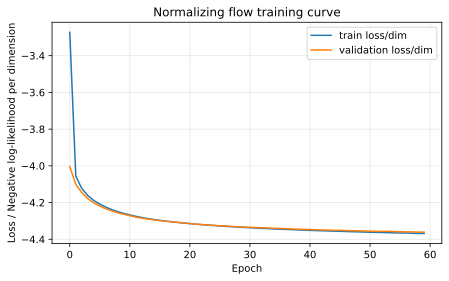

In [ ]:
train_loss_curve = history.get('train_loss_per_dim', history.get('train_loss', history['train_nll']))
val_loss_curve = history.get('val_loss_per_dim', history.get('val_loss', history['val_nll']))
y_label = 'Loss / Negative log-likelihood per dimension'

plt.figure(figsize=(7, 4))
plt.plot(train_loss_curve, label='train loss/dim')
plt.plot(val_loss_curve, label='validation loss/dim')
plt.xlabel('Epoch')
plt.ylabel(y_label)
plt.title('Normalizing flow training curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Samples


Samples generated from the Gaussian prior:


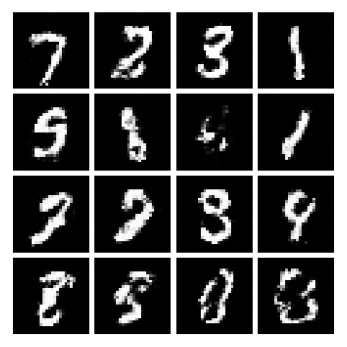

In [14]:
model.eval()

print('Samples generated from the Gaussian prior:')
with torch.no_grad():
    generated = model.sample(16).cpu()
show_imgs(generated)


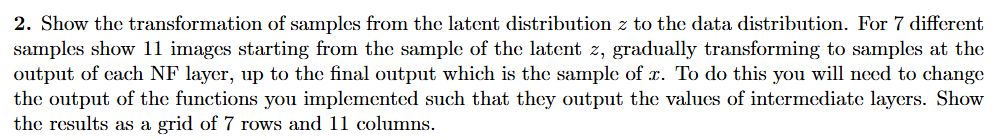

## Task 2: Latent-to-Data Transformation


In [15]:
def load_nf_state_dict(model, state_dict):
    try:
        model.load_state_dict(state_dict)
    except RuntimeError:
        renamed_state_dict = {key.replace('.t_net.', '.m_net.'): value for key, value in state_dict.items()}
        model.load_state_dict(renamed_state_dict)


def load_trained_nf_for_transformations():
    global model

    checkpoint_file = os.path.join(CHECKPOINT_PATH, 'nf_model.pth')

    if os.path.exists(checkpoint_file):
        checkpoint = torch.load(checkpoint_file, map_location=device)
        checkpoint_version = checkpoint.get('model_version') if isinstance(checkpoint, dict) else None
        if checkpoint_version != MODEL_VERSION:
            raise RuntimeError(
                f'Found {checkpoint_file}, but it was saved with model_version={checkpoint_version}. '
                f'Re-run Task 1 training to create a {MODEL_VERSION} checkpoint.'
            )

        model = NormalizingFlow(
            input_dim=checkpoint.get('input_dim', 28 * 28),
            num_layers=checkpoint.get('num_layers', 10),
            hidden_dim=checkpoint.get('hidden_dim', 256),
            image_shape=tuple(checkpoint.get('image_shape', (1, 28, 28))),
            alpha=checkpoint.get('alpha', 1e-5),
        ).to(device)
        load_nf_state_dict(model, checkpoint['model_state_dict'])

        model.eval()
        print(f'Loaded trained normalizing flow from {checkpoint_file}')
        return model

    if 'model' in globals() and isinstance(model, NormalizingFlow):
        model.eval()
        print('Using the current NormalizingFlow model from memory.')
        return model

    raise RuntimeError('Run the Task 1 training cell first, or make sure nf_model.pth exists in CHECKPOINT_PATH.')


def sample_nf_with_intermediates(model, num_samples):
    nf_model = getattr(model, '_orig_mod', model)
    return nf_model.sample(num_samples, return_intermediates=True)


model = load_trained_nf_for_transformations()

num_transform_samples = 7
with torch.no_grad():
    x_samples, layer_values = sample_nf_with_intermediates(model, num_transform_samples)

assert layer_values.shape == (num_transform_samples, model.num_layers + 1, 1, 28, 28)
assert x_samples.shape == (num_transform_samples, 1, 28, 28)

print('Layer values shape:', tuple(layer_values.shape))
print('Number of columns:', layer_values.shape[1])


Loaded trained normalizing flow from ./nf_model.pth
Layer values shape: (7, 11, 1, 28, 28)
Number of columns: 11


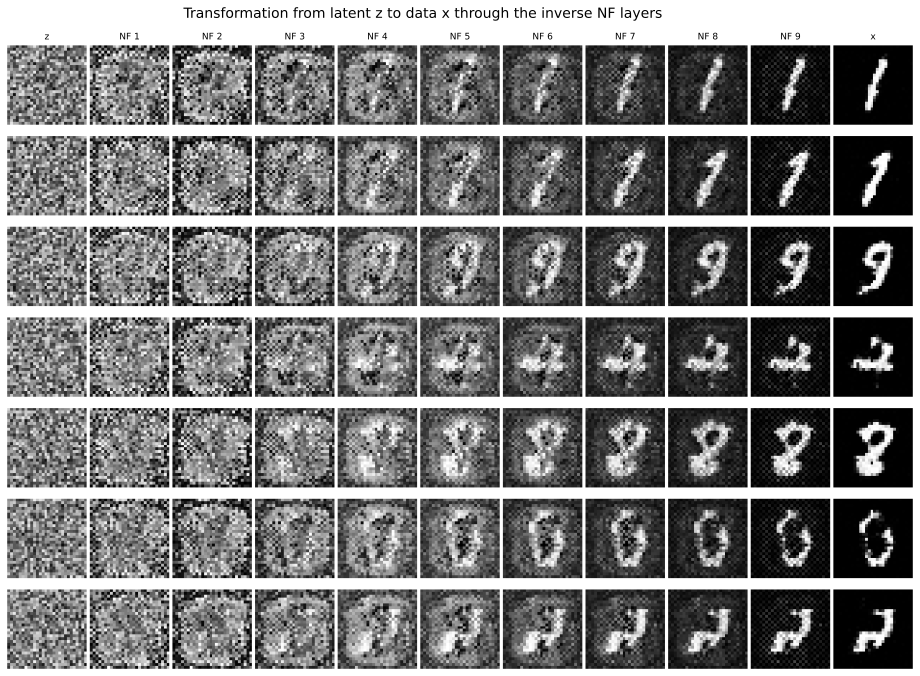

In [16]:
def plot_latent_to_data_transformation(layer_values):
    num_samples, num_steps = layer_values.shape[:2]
    display_values = layer_values.detach().cpu().clamp(0, 1)

    fig, axes = plt.subplots(
        num_samples,
        num_steps,
        figsize=(1.25 * num_steps, 1.35 * num_samples),
    )

    column_titles = ['z'] + [f'NF {idx}' for idx in range(1, num_steps - 1)] + ['x']

    for row_idx in range(num_samples):
        for col_idx in range(num_steps):
            axes[row_idx, col_idx].imshow(display_values[row_idx, col_idx, 0], cmap='gray', vmin=0, vmax=1)
            axes[row_idx, col_idx].axis('off')

            if row_idx == 0:
                axes[row_idx, col_idx].set_title(column_titles[col_idx], fontsize=9, pad=6)

        axes[row_idx, 0].set_ylabel(
            f'sample {row_idx + 1}',
            rotation=0,
            labelpad=32,
            va='center',
            ha='right',
            fontsize=9,
        )

    fig.suptitle('Transformation from latent z to data x through the inverse NF layers', fontsize=14, y=0.995)
    plt.subplots_adjust(left=0.08, right=0.995, top=0.94, bottom=0.02, wspace=0.04, hspace=0.12)
    plt.show()


plot_latent_to_data_transformation(layer_values)


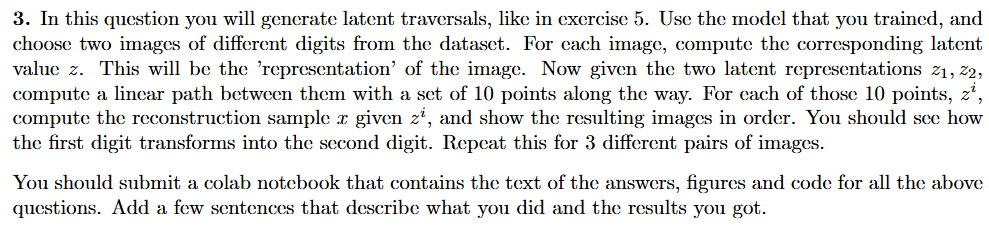

## Task 3: Latent Traversals


In [21]:
def first_index_for_digit(dataset, digit):
    """
    Finds the index of the first occurrence of a specific digit in a dataset.
    
    This function handles both standard PyTorch Datasets and Subset objects 
    by resolving the correct underlying indices.

    Args:
        dataset (torch.utils.data.Dataset): The dataset containing images and labels.
        digit (int): The target class label (e.g., 5) to search for.

    Returns:
        int: The local index of the first image matching the specified digit.
        
    Raises:
        ValueError: If the requested digit does not exist in the dataset.
    """
    # Resolve target labels depending on whether the dataset is a Subset or a full Dataset
    targets = dataset.dataset.targets if isinstance(dataset, torch.utils.data.Subset) else dataset.targets
    # Resolve the iterable indices mapping
    indices = dataset.indices if isinstance(dataset, torch.utils.data.Subset) else range(len(dataset))

    for local_idx, original_idx in enumerate(indices):
        if int(targets[original_idx]) == digit:
            return local_idx

    raise ValueError(f'Digit {digit} was not found in the dataset.')


def get_fixed_digit_pairs(dataset, digit_pairs):
    """
    Extracts explicit image pairs from the dataset corresponding to given label pairs.
    
    Args:
        dataset (torch.utils.data.Dataset): The dataset to sample from.
        digit_pairs (list of tuples): A list of (digit_a, digit_b) tuples specifying 
                                      the transitions to visualize (e.g., [(5, 7), (3, 8)]).

    Returns:
        tuple: A tuple containing two lists:
            - image_pairs: List of (img_a, img_b) tensor tuples.
            - label_pairs: List of (label_a, label_b) integer tuples.
    """
    image_pairs = []
    label_pairs = []

    for digit_a, digit_b in digit_pairs:
        # Retrieve the exact indices for the desired source and target classes
        idx_a = first_index_for_digit(dataset, digit_a)
        idx_b = first_index_for_digit(dataset, digit_b)
        
        # Extract the image tensors and their corresponding labels
        img_a, label_a = dataset[idx_a]
        img_b, label_b = dataset[idx_b]

        # Sanity check to ensure we are actually interpolating between two distinct classes
        assert int(label_a) != int(label_b), "Interpolation requires two distinct digit classes."
        
        image_pairs.append((img_a, img_b))
        label_pairs.append((int(label_a), int(label_b)))

    return image_pairs, label_pairs


def encode_with_nf(model, x):
    """
    Maps an image from the data manifold (X) to the continuous latent space (Z).
    
    In Normalizing Flows, the forward pass calculates both the latent vector 'z' 
    and the log-determinant of the Jacobian. For latent traversals, we only 
    care about the coordinate position in Z, so we discard the Jacobian term.

    Args:
        model (nn.Module): The trained Normalizing Flow model.
        x (torch.Tensor): The input image tensor.

    Returns:
        torch.Tensor: The encoded latent vector representation (z).
    """
    z, _ = model.forward(x)
    return z


# =============================================================================
# Execution Block: Latent Space Traversal
# =============================================================================

# Load the trained flow model and set it to evaluation mode to disable gradients,
# dropout, and other training-specific behaviors.
model = load_trained_nf_for_transformations()
model.eval()

# Define traversal hyperparameters
num_steps = 10  # Number of intermediate frames in the morphing animation
digit_pairs = [(5, 7), (3, 8), (4, 9)] # The source -> target semantic transitions

# Create a linear interpolation schedule (alpha) from 0.0 to 1.0.
# alpha=0 corresponds to 100% Image A, alpha=1 corresponds to 100% Image B.
alphas = torch.linspace(0, 1, num_steps, device=device)

# Retrieve the actual image tensors for our defined pairs
image_pairs, label_pairs = get_fixed_digit_pairs(test_set, digit_pairs)

latent_rows = []

# We use torch.no_grad() because we are performing inference. We do not need 
# to build computational graphs or track gradients, which saves significant VRAM.
with torch.no_grad():
    for img_a, img_b in image_pairs:
        # Add a batch dimension (B, C, H, W) and move to GPU
        x_a = img_a.unsqueeze(0).to(device)
        x_b = img_b.unsqueeze(0).to(device)

        # Step 1: Encoder
        # Map the complex pixel data to the simple Gaussian prior space: z = f(x)
        z_a = encode_with_nf(model, x_a)
        z_b = encode_with_nf(model, x_b)

        # Step 2: Linear Interpolation in Latent Space
        # We reshape alpha to (num_steps, 1) to allow PyTorch broadcasting.
        # This creates a matrix of 10 intermediate z-vectors mathematically spaced 
        # on a straight line between z_a and z_b.
        alpha_z = alphas.view(num_steps, 1)
        z_path = (1 - alpha_z) * z_a + alpha_z * z_b
        
        # Step 3: Decoder
        # Map the 10 interpolated latent vectors back to the image manifold: x = f^{-1}(z)
        # We clamp the output to [0.0, 1.0] to ensure valid pixel intensities,
        # correcting any minor numerical drifts caused by the inverse logit transform.
        x_path = model.inverse(z_path).clamp(0.0, 1.0)

        # Store the resulting batch of 10 morphing images on the CPU to free GPU memory
        latent_rows.append(x_path.cpu())

# Stack the results into a single comprehensive tensor for visualization.
# Shape will be: (num_pairs, num_steps, Channels, Height, Width)
latent_traversals = torch.stack(latent_rows)

# Final Sanity Checks
assert all(a != b for a, b in label_pairs), "Found identical source and target labels."
assert latent_traversals.shape == (3, num_steps, 1, 28, 28), "Unexpected output tensor shape."

print('Selected digit pairs:', label_pairs)
print('Latent traversal shape:', tuple(latent_traversals.shape))

Loaded trained normalizing flow from ./nf_model.pth
Selected digit pairs: [(5, 7), (3, 8), (4, 9)]
Latent traversal shape: (3, 10, 1, 28, 28)


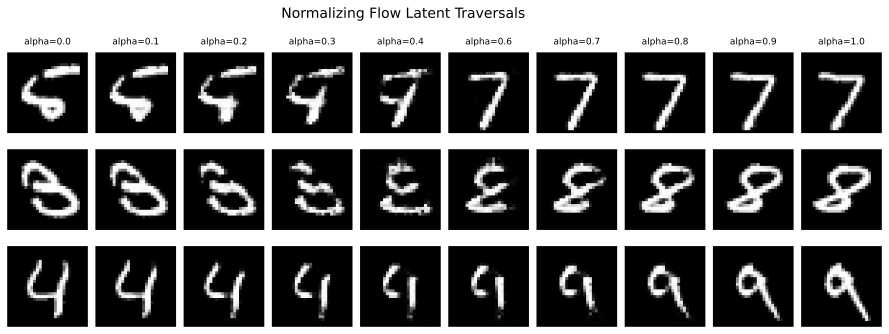

In [22]:
def plot_nf_latent_traversals(latent_traversals, label_pairs, alphas):
    num_pairs, num_steps = latent_traversals.shape[:2]
    fig, axes = plt.subplots(
        num_pairs,
        num_steps,
        figsize=(1.35 * num_steps, 1.55 * num_pairs),
    )

    if num_pairs == 1:
        axes = axes[None, :]

    for pair_idx, (digit_a, digit_b) in enumerate(label_pairs):
        for step_idx in range(num_steps):
            axes[pair_idx, step_idx].imshow(
                latent_traversals[pair_idx, step_idx, 0], cmap='gray', vmin=0, vmax=1
            )
            axes[pair_idx, step_idx].axis('off')

            if pair_idx == 0:
                axes[pair_idx, step_idx].set_title(
                    f'alpha={alphas[step_idx].item():.1f}', fontsize=9, pad=8
                )

        axes[pair_idx, 0].set_ylabel(
            f'{digit_a} -> {digit_b}',
            rotation=0,
            labelpad=34,
            va='center',
            ha='right',
            fontsize=10,
        )

    fig.suptitle('Normalizing Flow Latent Traversals', fontsize=14, y=0.995)
    plt.subplots_adjust(left=0.09, right=0.995, top=0.86, bottom=0.04, wspace=0.04, hspace=0.20)
    plt.show()


plot_nf_latent_traversals(latent_traversals, label_pairs, alphas.cpu())
